In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.applications import EfficientNetV2M
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from math import ceil
import shutil
import tqdm
import random
from PIL import Image
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.applications import EfficientNetV2B0, EfficientNetV2B1, EfficientNetV2B2, EfficientNetV2B3, EfficientNetV2M

In [3]:
!unzip /content/drive/MyDrive/SU25QN23/Dataset/dataset_2107.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/dataset_2107/snake/0973.jpg  
  inflating: /content/dataset/dataset_2107/snake/0974.jpg  
  inflating: /content/dataset/dataset_2107/snake/0975.jpg  
  inflating: /content/dataset/dataset_2107/snake/0976.jpg  
  inflating: /content/dataset/dataset_2107/snake/0977.jpg  
  inflating: /content/dataset/dataset_2107/snake/0978.jpg  
  inflating: /content/dataset/dataset_2107/snake/0979.jpg  
  inflating: /content/dataset/dataset_2107/snake/0980.jpg  
  inflating: /content/dataset/dataset_2107/snake/0981.jpg  
  inflating: /content/dataset/dataset_2107/snake/0982.jpg  
  inflating: /content/dataset/dataset_2107/snake/0983.jpg  
  inflating: /content/dataset/dataset_2107/snake/0984.jpg  
  inflating: /content/dataset/dataset_2107/snake/0985.jpg  
  inflating: /content/dataset/dataset_2107/snake/0986.jpg  
  inflating: /content/dataset/dataset_2107/snake/0987.jpg  
  inflating: /content/dataset/dataset_2107/snake/

In [4]:
DATA_DIR = '/content/dataset/dataset_2107'
all_class=os.listdir(DATA_DIR)
folder_count = 0
try:
    for item_name in all_class:
        item_path = os.path.join(DATA_DIR, item_name)
        if os.path.isdir(item_path):
            folder_count += 1

    print(f"{folder_count} class ")
except FileNotFoundError:
    print(f"Không tìm thấy đường dẫn: {DATA_DIR}")

all_class

46 class 


['cucumber',
 'fish',
 'jackfruit',
 'papaya',
 'butterfly',
 'jelly_fish',
 'mouse',
 'pig',
 'ginger',
 'snake',
 'horse',
 'peacock',
 'dragon_fruits',
 'deer',
 'cow',
 'rice_plant',
 'panther',
 'cabbage',
 'bee',
 'buffalo',
 'litchi',
 'goat',
 'lion',
 'seal',
 'tomato',
 'beans',
 'dog',
 'tiger',
 'zebra',
 'elephant',
 'lotus',
 'cat',
 'fox',
 'chipmunk',
 'cauliflower',
 'bird',
 'longan',
 'maize',
 'orchid',
 'rabbit',
 'spider',
 'coffee',
 'ape',
 'turtle',
 'chicken',
 'potato']

In [5]:
target_root = '/content/dataset_split'
TRAIN_RATIO = 0.8

TRAIN_DIR = os.path.join(target_root, "train")
VAL_DIR = os.path.join(target_root, "val")

def is_valid_image(path):
    try:
        img = Image.open(path)
        img.verify()
        return True
    except:
        return False

def count_all_images(root):
    total = 0
    for path, _, files in os.walk(root):
        total += len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    return total

if os.path.exists(target_root):
    shutil.rmtree(target_root)
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)

print("Tổng ảnh gốc:", count_all_images(DATA_DIR))

for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_path):
        continue

    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg','.jpeg','.png'))
              and is_valid_image(os.path.join(class_path, f))]

    if len(images) == 0:
        print(f"Bỏ qua {class_name} vì không có ảnh.")
        continue

    random.shuffle(images)
    total = len(images)
    train_end = int(total * TRAIN_RATIO)

    split_lists = {
        TRAIN_DIR: images[:train_end],
        VAL_DIR: images[train_end:]}

    for split_dir, file_list in split_lists.items():
        split_class_dir = os.path.join(split_dir, class_name)
        os.makedirs(split_class_dir, exist_ok=True)

        for fname in tqdm.tqdm(file_list, desc=f"Copy {class_name} -> {split_dir}"):
            src_path = os.path.join(class_path, fname)
            dst_path = os.path.join(split_class_dir, fname)
            shutil.copy2(src_path, dst_path)

print(f"Hoàn tất chia dữ liệu. Tổng ảnh sau chia: {count_all_images(target_root)}")

Tổng ảnh gốc: 44842


Copy peacock -> /content/dataset_split/val: 100%|██████████| 184/184 [00:00<00:00, 1014.79it/s]
Copy dragon_fruits -> /content/dataset_split/train: 100%|██████████| 800/800 [00:00<00:00, 6775.31it/s]
Copy potato -> /content/dataset_split/val: 100%|██████████| 200/200 [00:00<00:00, 4589.98it/s]

Hoàn tất chia dữ liệu. Tổng ảnh sau chia: 44842


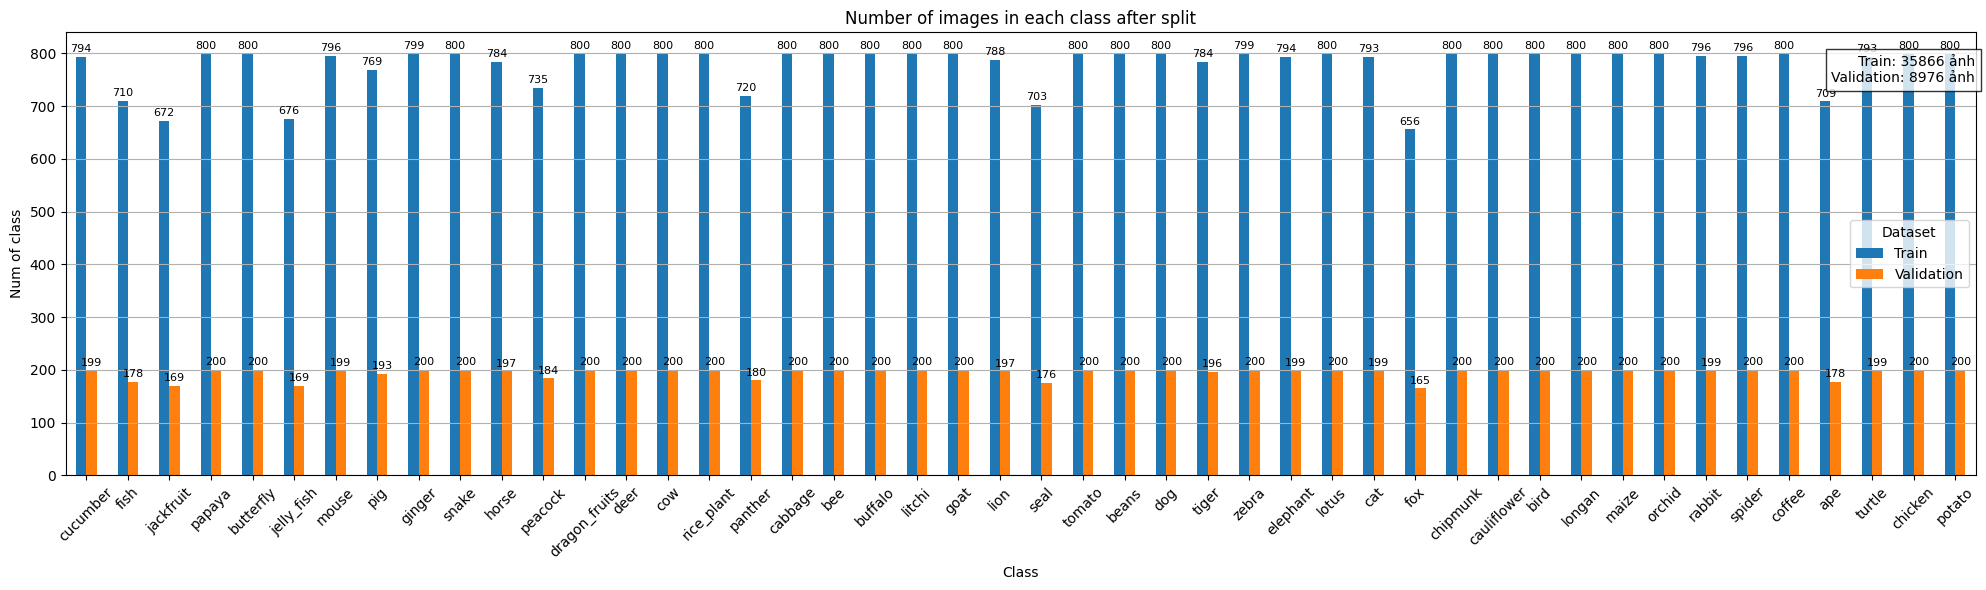

In [6]:
base_dirs = {
    'Train': '/content/dataset_split/train',
    'Validation': '/content/dataset_split/val',}
class_counts = {}
split_totals = {}

for split_name, split_path in base_dirs.items():
    total = 0
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            total += count
            if class_name not in class_counts:
                class_counts[class_name] = {}
            class_counts[class_name][split_name] = count
    split_totals[split_name] = total

df = pd.DataFrame(class_counts).T.fillna(0).astype(int)
ax = df.plot(kind='bar', figsize=(20, 6))

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=8, padding=2)

summary_text = "\n".join([f"{split}: {count} ảnh" for split, count in split_totals.items()])
plt.gcf().text(0.99, 0.90, summary_text, fontsize=10, ha='right', va='top',
               bbox=dict(facecolor='white', alpha=0.8))

plt.title('Number of images in each class after split')
plt.xlabel('Class')
plt.ylabel('Num of class')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()


## MODEL

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
EPOCHS = 30
LR = 1e-4
OUTPUT_DIR = '/content/drive/MyDrive/SU25QN23/Modeling/EfficientNetV2M_finaldata_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [8]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)
class_names = train_ds.class_names
NUM_CLASSES = len(train_ds.class_names)

train_ds = train_ds.shuffle(500).map(lambda x, y: (preprocess_input(x), y),num_parallel_calls=4).prefetch(1)
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

Found 35866 files belonging to 46 classes.
Found 8976 files belonging to 46 classes.


Found 35866 files belonging to 46 classes.
Shape ảnh: (1, 224, 224, 3)
Ma trận pixel (top-left 5x5):
 [[[244.07143 238.07143 242.07143]
  [245.21428 239.21428 243.21428]
  [246.35715 240.35715 244.35715]
  [247.5     241.5     245.5    ]
  [248.64285 242.64285 246.64285]]

 [[244.05612 238.05612 242.05612]
  [245.      239.      243.     ]
  [246.21939 240.21939 244.21939]
  [247.5     241.5     245.5    ]
  [248.64285 242.64285 246.64285]]

 [[244.      238.      242.     ]
  [244.21428 238.21428 242.21428]
  [245.58673 239.58673 243.58673]
  [247.14285 241.14285 245.14285]
  [248.2857  242.2857  246.2857 ]]

 [[243.5357  237.5357  241.5357 ]
  [244.21428 238.21428 242.21428]
  [245.35715 239.35715 243.35715]
  [246.5     240.5     244.5    ]
  [247.64285 241.64285 245.64285]]

 [[243.02551 237.02551 241.02551]
  [243.57143 237.57143 241.57143]
  [244.7143  238.7143  242.7143 ]
  [246.17857 240.17857 244.17857]
  [247.64285 241.64285 245.64285]]]


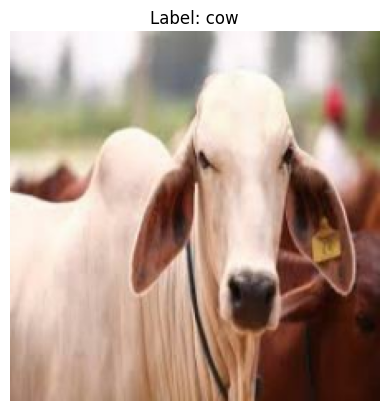

In [9]:
sample_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=1,
    label_mode="categorical"
)

sample_img, sample_label = next(iter(sample_ds))
print("Shape ảnh:", sample_img.shape)
print("Ma trận pixel (top-left 5x5):\n", sample_img[0, :5, :5, :].numpy())

plt.imshow(sample_img[0].numpy().astype("uint8"))

label_index = int(tf.argmax(sample_label[0]).numpy())
plt.title(f"Label: {class_names[label_index]}")

plt.axis("off")
plt.show()


In [10]:
base_model = EfficientNetV2M(include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

214201816/214201816 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [11]:
inputs = layers.Input(shape=(*IMG_SIZE, 3), batch_size=BATCH_SIZE)
print("Ma trận input (1 ảnh batch):\n", sample_img[0].numpy()[:5, :5, :])

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)

for units in [256]:
    x = layers.Dense(units, use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = layers.ReLU()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype="float32")(x)
model = Model(inputs, outputs)

Ma trận input (1 ảnh batch):
 [[[244.07143 238.07143 242.07143]
  [245.21428 239.21428 243.21428]
  [246.35715 240.35715 244.35715]
  [247.5     241.5     245.5    ]
  [248.64285 242.64285 246.64285]]

 [[244.05612 238.05612 242.05612]
  [245.      239.      243.     ]
  [246.21939 240.21939 244.21939]
  [247.5     241.5     245.5    ]
  [248.64285 242.64285 246.64285]]

 [[244.      238.      242.     ]
  [244.21428 238.21428 242.21428]
  [245.58673 239.58673 243.58673]
  [247.14285 241.14285 245.14285]
  [248.2857  242.2857  246.2857 ]]

 [[243.5357  237.5357  241.5357 ]
  [244.21428 238.21428 242.21428]
  [245.35715 239.35715 243.35715]
  [246.5     240.5     244.5    ]
  [247.64285 241.64285 245.64285]]

 [[243.02551 237.02551 241.02551]
  [243.57143 237.57143 241.57143]
  [244.7143  238.7143  242.7143 ]
  [246.17857 240.17857 244.17857]
  [247.64285 241.64285 245.64285]]]


In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (8, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-m (Functional)   │ (8, 7, 7, 1280)        │    53,150,388 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (8, 1280)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (8, 256)               │       327,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (8, 256)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (8, 256)               │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (8, 256)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (8, 46)                │        11,822 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,490,914 (204.05 MB)

 Trainable params: 340,014 (1.30 MB)

 Non-trainable params: 53,150,900 (202.75 MB)

In [13]:
#model_path = os.path.join(OUTPUT_DIR, 'EF_best_model_2.keras')
model_path = log_path = os.path.join(OUTPUT_DIR, 'EF_best_model_3.keras')
log_path = os.path.join(OUTPUT_DIR, 'EF_training_log_3.csv')
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(model_path, save_best_only=True, monitor="val_loss", verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, cooldown=1, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.CSVLogger(log_path)
]

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
4484/4484 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7314 - loss: 1.5726
Epoch 1: val_loss improved from inf to 0.58027, saving model to /content/drive/MyDrive/SU25QN23/Modeling/EfficientNetV2M_finaldata_output/EF_best_model_3.keras
4484/4484 ━━━━━━━━━━━━━━━━━━━━ 468s 85ms/step - accuracy: 0.7314 - loss: 1.5724 - val_accuracy: 0.9503 - val_loss: 0.5803 - learning_rate: 1.0000e-04
Epoch 2/30
4483/4484 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9407 - loss: 0.6064
Epoch 2: val_loss improved from 0.58027 to 0.48956, saving model to /content/drive/MyDrive/SU25QN23/Modeling/EfficientNetV2M_finaldata_output/EF_best_model_3.keras
4484/4484 ━━━━━━━━━━━━━━━━━━━━ 317s 69ms/step - accuracy: 0.9407 - loss: 0.6064 - val_accuracy: 0.9609 - val_loss: 0.4896 - learning_rate: 1.0000e-04
Epoch 3/30
4484/4484 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9559 - loss: 0.4945
Epoch 3: val_loss improved from 0.48956 to 0.42693, saving model to /content/drive/MyDrive/SU25QN23/Modeling/

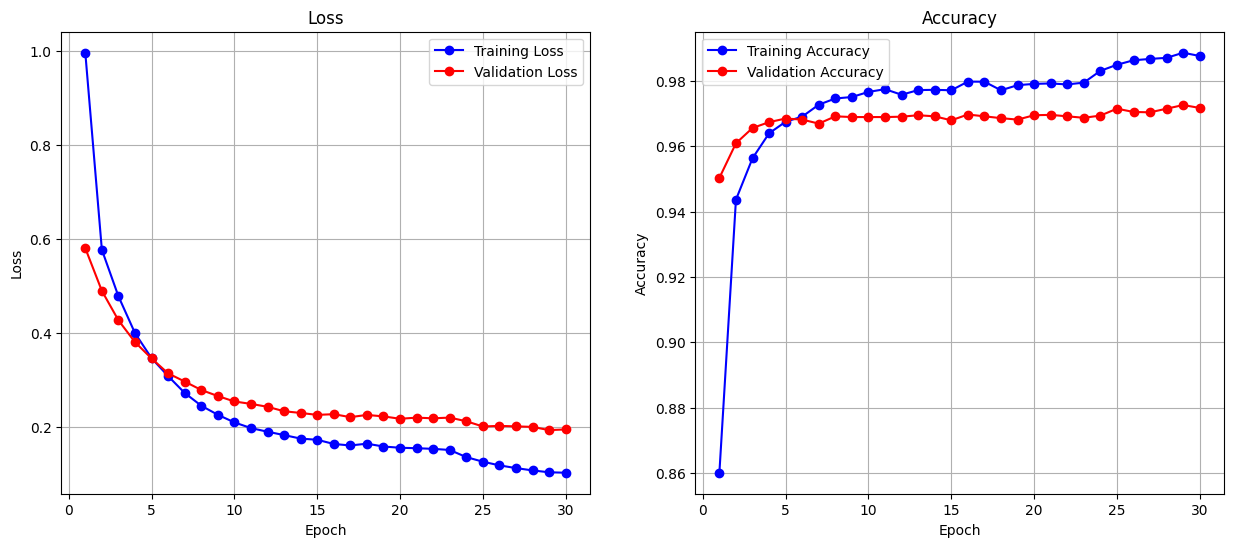

In [15]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(loss) + 1)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, 'bo-', label='Training Loss')
plt.plot(epochs_range, val_loss, 'ro-', label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

## TEST

In [16]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [17]:
!unzip "/content/drive/MyDrive/SU25QN23/Dataset/test.zip" -d "/content/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/test/cow/0122.jpeg  
  inflating: /content/test/cow/0123.jpeg  
  inflating: /content/test/cow/0124.jpeg  
  inflating: /content/test/cow/0125.jpeg  
  inflating: /content/test/cow/0126.jpeg  
  inflating: /content/test/cow/0127.jpeg  
  inflating: /content/test/cow/0128.jpeg  
  inflating: /content/test/cow/0129.jpeg  
  inflating: /content/test/cow/0130.jpeg  
  inflating: /content/test/cow/0131.jpeg  
  inflating: /content/test/cow/0132.jpeg  
  inflating: /content/test/cow/0133.jpg  
  inflating: /content/test/cow/0134.jpeg  
  inflating: /content/test/cow/0135.jpeg  
  inflating: /content/test/cow/0136.jpeg  
  inflating: /content/test/cow/0137.jpeg  
  inflating: /content/test/cow/0138.jpeg  
  inflating: /content/test/cow/0139.jpeg  
  inflating: /content/test/cow/0140.jpeg  
  inflating: /content/test/cow/0141.jpeg  
  inflating: /content/test/cow/0142.png  
  inflating: /content/test/cow/0143.jpeg  
  inf

In [18]:
TEST_DIR = '/content/test'
preprocess_input = tf.keras.applications.efficientnet_v2.preprocess_input

In [19]:
class_names = [
    'ape', 'beans', 'bee', 'bird', 'buffalo', 'butterfly', 'cabbage',
    'cauliflower', 'cat', 'chicken', 'chipmunk', 'coffee', 'cow',
    'cucumber', 'deer', 'dog', 'dragon_fruits', 'elephant', 'fish',
    'fox', 'ginger', 'goat', 'horse', 'jackfruit', 'jelly_fish',
    'lion', 'litchi', 'longan', 'lotus', 'maize', 'mouse', 'orchid',
    'panther', 'papaya', 'peacock', 'pig', 'potato', 'rabbit',
    'rice_plant', 'seal', 'snake', 'spider', 'tiger', 'tomato',
    'turtle', 'zebra'
]

In [20]:
MODEL_PATH = os.path.join(OUTPUT_DIR, 'EF_best_model_3.keras')
model = load_model(MODEL_PATH)

In [21]:
test_filepaths = []
test_labels = []
for folder in os.listdir(TEST_DIR):
    folder_path = os.path.join(TEST_DIR, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            test_filepaths.append(file_path)
            test_labels.append(folder)

test_df = pd.DataFrame({
    'filepaths': test_filepaths,
    'labels': test_labels
})

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=16,
    shuffle=False,
    classes=class_names
)


Found 6738 validated image filenames belonging to 46 classes.


In [22]:
predictions = model.predict(test_gen, steps=len(test_gen), verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_gen.classes
print(classification_report(true_classes, predicted_classes, target_names=class_names))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


422/422 ━━━━━━━━━━━━━━━━━━━━ 222s 466ms/step
               precision    recall  f1-score   support

          ape       0.92      0.85      0.88       150
        beans       0.87      0.65      0.74       150
          bee       0.97      0.89      0.93       150
         bird       0.98      0.92      0.95       150
      buffalo       0.93      0.85      0.89       150
    butterfly       0.97      0.97      0.97       150
      cabbage       0.99      0.99      0.99       150
  cauliflower       0.00      0.00      0.00       150
          cat       0.00      0.00      0.00       150
      chicken       0.99      0.99      0.99       150
     chipmunk       0.93      0.99      0.96       150
       coffee       0.00      0.00      0.00         0
          cow       0.94      0.89      0.91       150
     cucumber       0.83      0.92      0.87       150
         deer       0.92      0.99      0.95       150
          dog       0.94      0.77      0.85       150
dragon_fruits      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
results = model.evaluate(test_gen, verbose=1)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

422/422 ━━━━━━━━━━━━━━━━━━━━ 213s 451ms/step - accuracy: 0.9134 - loss: 0.8270
Test Loss: 1.4993
Test Accuracy: 0.8707


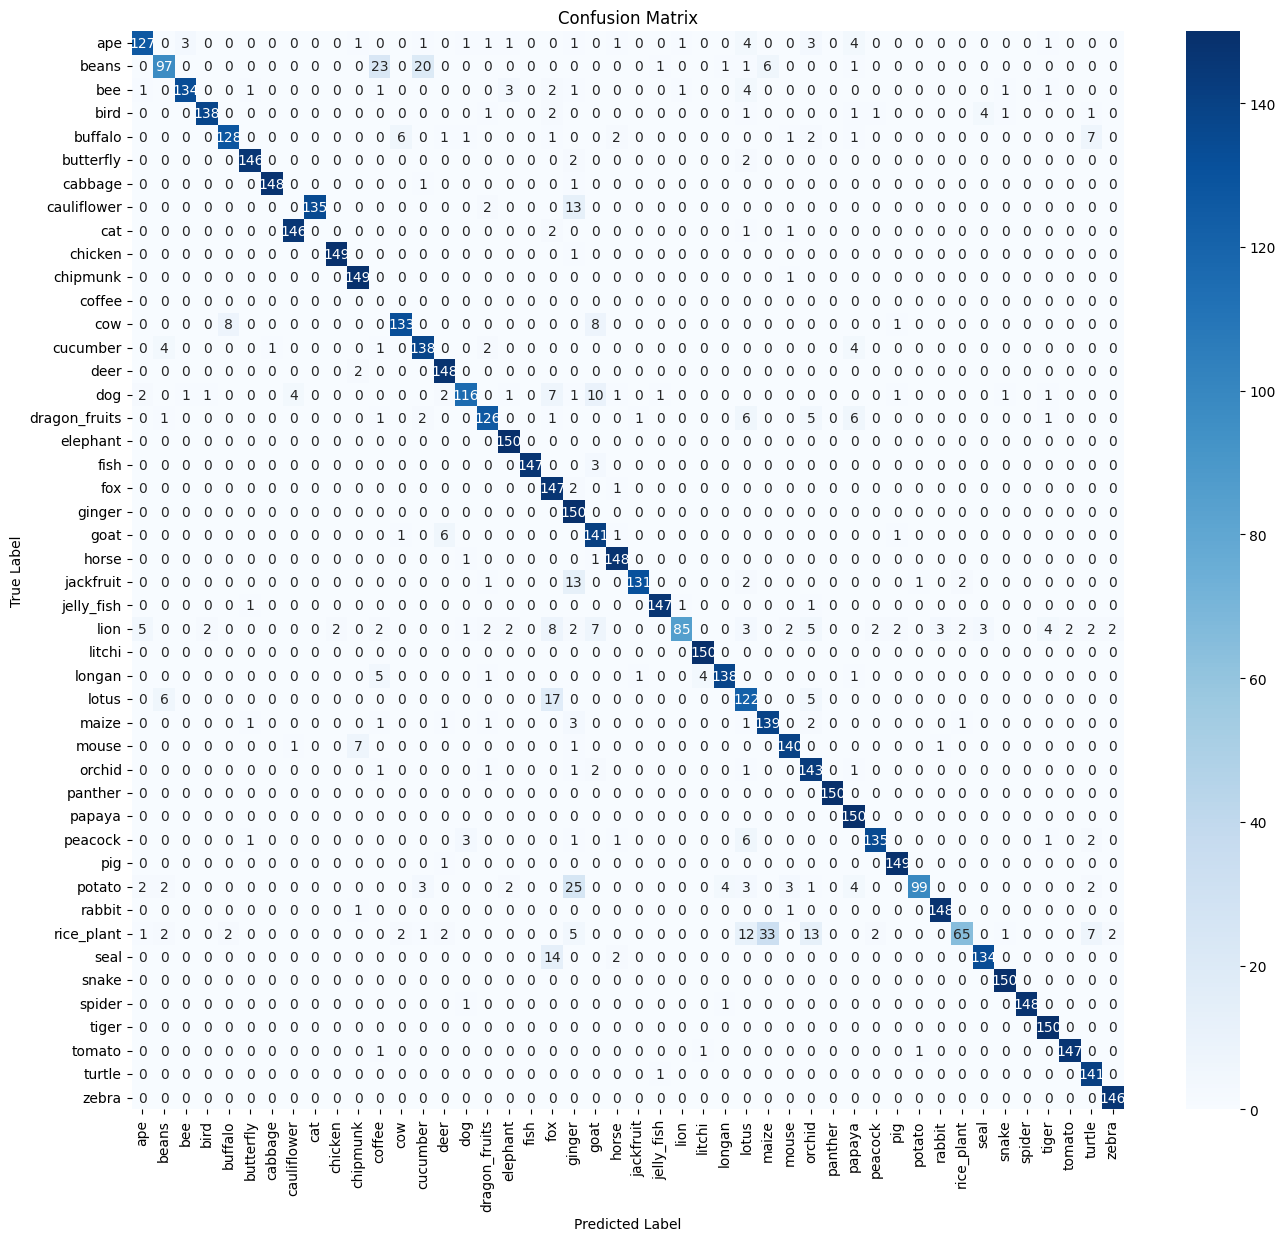

In [24]:
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


## 1 img

In [25]:
def predict_single_image(image_path, loaded_model, class_names_list):
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array_expanded = np.expand_dims(img_array, axis=0)
    preprocessed_img = preprocess_input(img_array_expanded)

    prediction = loaded_model.predict(preprocessed_img)

    predicted_class_index = np.argmax(prediction, axis=1)[0]
    predicted_class_name = class_names_list[predicted_class_index]
    confidence = np.max(prediction) * 100

    plt.figure(figsize=(6, 7))
    plt.imshow(img)
    title = f"Dự đoán: {predicted_class_name.upper()}\nĐộ tin cậy: {confidence:.2f}%"
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 26s 26s/step


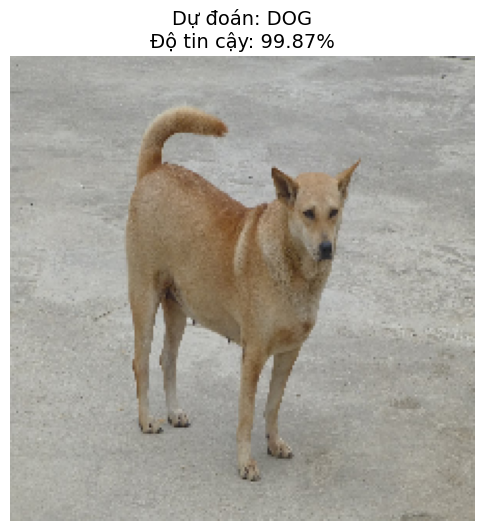

In [26]:
TEST_IMAGE_PATH = '/content/drive/MyDrive/SU25QN23/Dataset/Test_img/1200px-Yen_Bai_-_dogs_-_P1390010.jpg'
predict_single_image(
    image_path=TEST_IMAGE_PATH,
    loaded_model=model,
    class_names_list=class_names
)